<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/HES20noClip003.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
# Act XLVIII: Harmonic Anchor
import numpy as np
import matplotlib.pyplot as plt

# Parameters
N_values = [50, 100, 200, 400]           # scale layers
lambda_dom_vals = np.linspace(0.5, 2.0, 20)  # sweep range
timesteps = 300
seed = 42
np.random.seed(seed)

def init_state(N):
    return np.random.normal(0, 1, N)


In [8]:
def evolve(state, timesteps, lambda_dom):
    history = []
    s = state.copy()
    for t in range(timesteps):
        s = s + lambda_dom * np.sin(s)
        history.append(s.copy())
    return np.array(history)


In [9]:
def stability_metric(history):
    final_var = np.var(history[-1])
    return final_var


In [10]:
results = {}

for N in N_values:
    scores = []
    for lam in lambda_dom_vals:
        state = init_state(N)
        hist = evolve(state, timesteps, lam)
        score = stability_metric(hist)
        scores.append(score)
    results[N] = scores


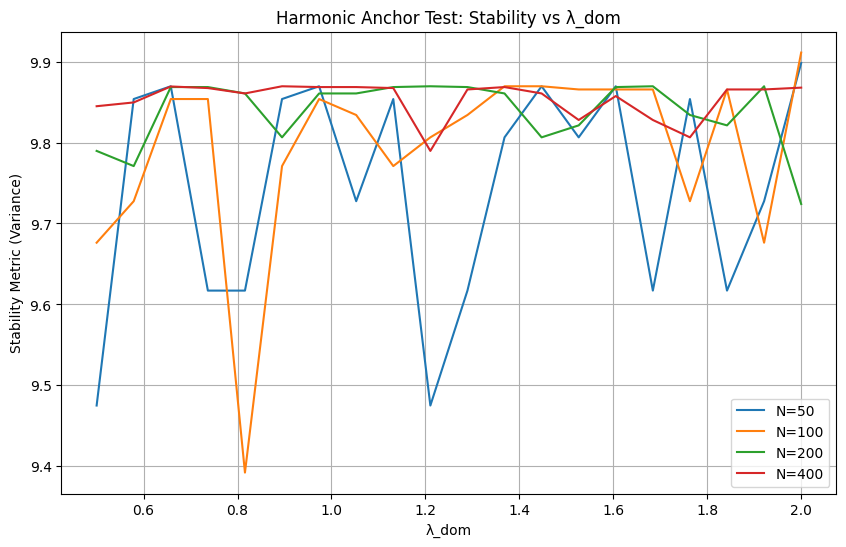

In [11]:
plt.figure(figsize=(10,6))
for N in N_values:
    plt.plot(lambda_dom_vals, results[N], label=f"N={N}")
plt.xlabel("λ_dom")
plt.ylabel("Stability Metric (Variance)")
plt.title("Harmonic Anchor Test: Stability vs λ_dom")
plt.legend()
plt.grid(True)
plt.show()
